In [1]:
# exp03 — GoogLeNet/InceptionV1 · Tiny ImageNet
# Acumula exp_001 (filtros 5a/5b reduzidos) + exp_002 (dropout 0.55)
# Hipótese: label smoothing + ReduceLROnPlateau + augmentation mais agressivo
# reduz underfitting da cabeça principal e empurra Top-1 acima de 42%.

import datetime

EXPERIMENTO = {
    "id": "exp_003",
    "hipotese": (
        "Label smoothing (0.1) + ReduceLROnPlateau + augmentation mais agressivo "
        "devem reduzir o gap entre saída auxiliar e principal, melhorando Top-1 acima de 42%."
    ),
    "mudancas": [
        "[exp_001] inception_5a: (256,160,320,32,128,128) → (192,128,256,32,96,96)",
        "[exp_001] inception_5b: (384,192,384,48,128,128) → (256,160,320,32,96,96)",
        "[exp_002] main_dropout: 0.4 → 0.55",
        "[exp_003] label_smoothing: 0.0 → 0.1",
        "[exp_003] scheduler: LRDecay fixo → ReduceLROnPlateau (patience=5, factor=0.5)",
        "[exp_003] augmentation: +RandomBrightness(0.2), RandomRotation 0.1→0.15",
    ],
    "resultado_top1": None,
    "resultado_top5": None,
    "epocas": None,
}

print(f"[{datetime.datetime.now():%Y-%m-%d %H:%M}] {EXPERIMENTO['id']}")
print(f"Hipótese: {EXPERIMENTO['hipotese']}")
print("\nMudanças acumuladas:")
for m in EXPERIMENTO["mudancas"]:
    print(f"  • {m}")


[2026-05-04 01:25] exp_003
Hipótese: Label smoothing (0.1) + ReduceLROnPlateau + augmentation mais agressivo devem reduzir o gap entre saída auxiliar e principal, melhorando Top-1 acima de 42%.

Mudanças acumuladas:
  • [exp_001] inception_5a: (256,160,320,32,128,128) → (192,128,256,32,96,96)
  • [exp_001] inception_5b: (384,192,384,48,128,128) → (256,160,320,32,96,96)
  • [exp_002] main_dropout: 0.4 → 0.55
  • [exp_003] label_smoothing: 0.0 → 0.1
  • [exp_003] scheduler: LRDecay fixo → ReduceLROnPlateau (patience=5, factor=0.5)
  • [exp_003] augmentation: +RandomBrightness(0.2), RandomRotation 0.1→0.15


## Histórico de Experimentos

| ID | Mudanças-chave | Top-1 val | Top-5 val | Δ Top-1 |
|---|---|---|---|---|
| baseline | Modelo original | 39.88% | — | — |
| exp_001 | inception_5a/5b: canais reduzidos ~30% | 40.08% | — | +0.20pp |
| exp_002 | main_dropout: 0.4 → 0.55 | 39.29%* | 71.79% | +1.08pp (principal) |
| **exp_003** | label_smoothing + ReduceLROnPlateau + aug+ | *(pendente)* | *(pendente)* | — |

> *O Top-1 do exp_002 reportado pelo `evaluate()` usa a saída principal (39.29%).
> A saída auxiliar atingiu 46.58% — gap de ~7pp que exp_003 visa reduzir.*


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools, math, csv, os, shutil, zipfile, warnings, datetime
import requests
from PIL import Image
from io import BytesIO
from pathlib import Path
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")


2026-05-04 01:25:42.349815: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777857942.561673      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777857942.625091      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777857943.123555      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777857943.123603      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777857943.123606      22 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Hiperparâmetros ──────────────────────────────────────────────────────────
EPOCHS       = 100
BATCH_SIZE   = 128
NUM_CLASSES  = 200
IMG_SIZE     = 64
INITIAL_LR   = 0.01
DROPOUT_MAIN = 0.55   # exp_002
LABEL_SMOOTH = 0.1    # exp_003 — novo

tf.random.set_seed(42)
np.random.seed(42)
print(f"{EPOCHS} épocas | batch {BATCH_SIZE} | {IMG_SIZE}×{IMG_SIZE} | {NUM_CLASSES} classes")
print(f"dropout={DROPOUT_MAIN} | label_smoothing={LABEL_SMOOTH}")


100 épocas | batch 128 | 64×64 | 200 classes
dropout=0.55 | label_smoothing=0.1


In [4]:
TINY_URL = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
DATA_DIR = Path('/kaggle/working/tiny-imagenet-200')
ZIP_PATH = Path('/kaggle/working/tiny-imagenet-200.zip')

if not ZIP_PATH.exists():
    print('Baixando Tiny ImageNet (~236 MB)...')
    r = requests.get(TINY_URL, stream=True)
    total = int(r.headers.get('content-length', 0))
    downloaded = 0
    with open(ZIP_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            f.write(chunk)
            downloaded += len(chunk)
            print(f'\r  {downloaded/1e6:.1f}/{total/1e6:.1f} MB', end='')
    print('\nDownload completo!')
else:
    print('ZIP já existe.')

if not DATA_DIR.exists():
    print('Extraindo...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/kaggle/working')
    print('Extração concluída.')
else:
    print('Dataset já extraído.')

# Reorganiza val/ → val_organized/class_id/img.JPEG
val_organized = DATA_DIR / 'val_organized'
if not val_organized.exists():
    print('Reorganizando val/...')
    val_organized.mkdir(parents=True)
    with open(DATA_DIR / 'val' / 'val_annotations.txt') as f:
        for line in f:
            fname, class_id = line.strip().split('\t')[:2]
            d = val_organized / class_id
            d.mkdir(exist_ok=True)
            shutil.copy(DATA_DIR / 'val' / 'images' / fname, d / fname)
    print(f'Val reorganizado: {len(list(val_organized.iterdir()))} classes')
else:
    print('val_organized já existe.')

TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = val_organized
print(f'Treino: {TRAIN_DIR} | Val: {VAL_DIR}')


Baixando Tiny ImageNet (~236 MB)...
  248.1/248.1 MB
Download completo!
Extraindo...
Extração concluída.
Reorganizando val/...
Val reorganizado: 200 classes
Treino: /kaggle/working/tiny-imagenet-200/train | Val: /kaggle/working/tiny-imagenet-200/val_organized


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, label_mode='categorical', shuffle=True, seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False
)
CLASS_NAMES = train_ds.class_names
print(f'Classes: {len(CLASS_NAMES)}')

def normalize(img, lbl):
    return tf.cast(img, tf.float32) / 255.0, lbl

# exp_003: augmentation mais agressivo — RandomBrightness + maior rotação
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),          # era 0.1
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.2),          # novo
], name='augmentation')

train_ds = (
    train_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (augment(img, training=True), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    val_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
print('Pipelines prontos.')


Found 100000 files belonging to 200 classes.


I0000 00:00:1777858000.069068      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 10000 files belonging to 200 classes.
Classes: 200
Pipelines prontos.


In [6]:
def inception_module(x, f1, f3r, f3, f5r, f5, fp, name):
    """Módulo Inception: 4 ramos paralelos (Szegedy et al., 2014)."""
    ki = 'glorot_uniform'
    bi = tf.keras.initializers.Constant(0.2)
    kw = dict(padding='same', activation='relu', kernel_initializer=ki, bias_initializer=bi)

    b1 = tf.keras.layers.Conv2D(f1,  (1,1), **kw, name=f'{name}_1x1')(x)

    b2 = tf.keras.layers.Conv2D(f3r, (1,1), **kw, name=f'{name}_3x3_reduce')(x)
    b2 = tf.keras.layers.Conv2D(f3,  (3,3), **kw, name=f'{name}_3x3')(b2)

    b3 = tf.keras.layers.Conv2D(f5r, (1,1), **kw, name=f'{name}_5x5_reduce')(x)
    b3 = tf.keras.layers.Conv2D(f5,  (5,5), **kw, name=f'{name}_5x5')(b3)

    b4 = tf.keras.layers.MaxPooling2D((3,3), strides=(1,1), padding='same', name=f'{name}_pool')(x)
    b4 = tf.keras.layers.Conv2D(fp,  (1,1), **kw, name=f'{name}_pool_proj')(b4)

    return tf.keras.layers.Concatenate(axis=-1, name=name)([b1, b2, b3, b4])


In [7]:
def build_googlenet(num_classes=200, img_size=64, dropout=0.55):
    """GoogLeNet adaptado para 64×64. Acumula mudanças de exp_001 e exp_002."""
    bi = tf.keras.initializers.Constant(0.2)
    conv_kw = dict(padding='same', activation='relu',
                   kernel_initializer='glorot_uniform', bias_initializer=bi)

    inp = tf.keras.layers.Input(shape=(img_size, img_size, 3), name='input')

    # Stem: 3×3 × 3 + 1 MaxPool (preserva 32×32 para imagens 64×64)
    x = tf.keras.layers.Conv2D(64,  (3,3), **conv_kw, name='stem_c1')(inp)
    x = tf.keras.layers.Conv2D(64,  (3,3), **conv_kw, name='stem_c2')(x)
    x = tf.keras.layers.Conv2D(192, (3,3), **conv_kw, name='stem_c3')(x)
    x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same', name='stem_pool')(x)

    # Bloco 3
    x = inception_module(x,  64,  96, 128, 16,  32,  32, 'inception_3a')
    x = inception_module(x, 128, 128, 192, 32,  96,  64, 'inception_3b')
    x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same', name='pool_3')(x)

    # Bloco 4
    x = inception_module(x, 192,  96, 208, 16,  48,  64, 'inception_4a')

    # Classificador Auxiliar (peso 0.3 na loss)
    aux = tf.keras.layers.AveragePooling2D((5,5), strides=3, padding='same', name='aux_pool')(x)
    aux = tf.keras.layers.Conv2D(128, (1,1), **conv_kw, name='aux_conv')(aux)
    aux = tf.keras.layers.Flatten(name='aux_flat')(aux)
    aux = tf.keras.layers.Dense(1024, activation='relu', name='aux_dense')(aux)
    aux = tf.keras.layers.Dropout(0.3, name='aux_drop')(aux)
    aux_out = tf.keras.layers.Dense(num_classes, activation='softmax', name='auxiliary_output')(aux)

    x = inception_module(x, 160, 112, 224, 24,  64,  64, 'inception_4b')
    x = inception_module(x, 128, 128, 256, 24,  64,  64, 'inception_4c')
    x = inception_module(x, 112, 144, 288, 32,  64,  64, 'inception_4d')
    x = inception_module(x, 256, 160, 320, 32, 128, 128, 'inception_4e')
    x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same', name='pool_4')(x)

    # Bloco 5 — canais reduzidos (exp_001)
    x = inception_module(x, 192, 128, 256, 32, 96, 96, 'inception_5a')  # 640ch
    x = inception_module(x, 256, 160, 320, 32, 96, 96, 'inception_5b')  # 768ch

    # Cabeça principal — dropout 0.55 (exp_002)
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x = tf.keras.layers.Dropout(dropout, name='main_dropout')(x)
    main_out = tf.keras.layers.Dense(num_classes, activation='softmax', name='main_output')(x)

    return tf.keras.Model(inputs=inp, outputs=[main_out, aux_out], name='GoogLeNet_exp003')


model = build_googlenet(NUM_CLASSES, IMG_SIZE, DROPOUT_MAIN)
model.summary()


Model: "GoogLeNet_exp003"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_c1 (Conv2D)    │ (None, 64, 64,    │      1,792 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_c2 (Conv2D)    │ (None, 64, 64,    │     36,928 │ stem_c1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_c3 (Conv2D)    │ (None, 64, 64,    │    110,784 │ stem_c2[0][0]     │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 32, 32,    │          0 │ stem_c3[0][0]     │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3_r… │ (None, 32, 32,    │     18,528 │ stem_pool[0][0]   │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5_r… │ (None, 32, 32,    │      3,088 │ stem_pool[0][0]   │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_pool   │ (None, 32, 32,    │          0 │ stem_pool[0][0]   │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_1x1    │ (None, 32, 32,    │     12,352 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3    │ (None, 32, 32,    │    110,720 │ inception_3a_3x3… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5    │ (None, 32, 32,    │     12,832 │ inception_3a_5x5… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_pool_… │ (None, 32, 32,    │      6,176 │ inception_3a_poo… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 32, 32,    │          0 │ inception_3a_1x1… │
│ (Concatenate)       │ 256)              │            │ inception_3a_3x3… │
│                     │                   │            │ inception_3a_5x5… │
│                     │                   │            │ inception_3a_poo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_3x3_r… │ (None, 32, 32,    │     32,896 │ inception_3a[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_5x5_r… │ (None, 32, 32,    │      8,224 │ inception_3a[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_pool   │ (None, 32, 32,    │          0 │ inception_3a[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,287,152 (39.24 MB)

 Trainable params: 10,287,152 (39.24 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# exp_003: label_smoothing=0.1 substitui o decay manual de LR por ReduceLROnPlateau
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=INITIAL_LR, momentum=0.9, nesterov=True),
    loss={
        'main_output':      tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
        'auxiliary_output': tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    },
    loss_weights={'main_output': 1.0, 'auxiliary_output': 0.3},
    metrics={'main_output': ['accuracy'], 'auxiliary_output': ['accuracy']},
)
print('Compilado com sucesso.')


Compilado com sucesso.


In [9]:
# exp_003: ReduceLROnPlateau substitui o scheduler de decaimento fixo
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_main_output_accuracy', factor=0.5,
        patience=5, min_lr=1e-5, verbose=1, mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_main_output_accuracy', patience=15,
        restore_best_weights=True, verbose=1, mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'googlenet_exp003_best.keras', monitor='val_main_output_accuracy',
        save_best_only=True, verbose=1, mode='max'
    ),
    tf.keras.callbacks.CSVLogger('training_log_exp003.csv'),
]


In [10]:
# Duplica labels para as 2 saídas do modelo
def dual_labels(img, lbl):
    return img, (lbl, lbl)

train_ds_dual = train_ds.map(dual_labels)
val_ds_dual   = val_ds.map(dual_labels)

print(f'Iniciando exp_003 — {EPOCHS} épocas máx.')
history = model.fit(
    train_ds_dual,
    validation_data=val_ds_dual,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Iniciando exp_003 — 100 épocas máx.
Epoch 1/100


I0000 00:00:1777858014.208903      73 service.cc:152] XLA service 0x7a14dc003110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777858014.208950      73 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777858016.235508      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777858053.004888      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - auxiliary_output_accuracy: 0.0051 - auxiliary_output_loss: 5.3122 - loss: 6.9189 - main_output_accuracy: 0.0050 - main_output_loss: 5.3252
Epoch 1: val_main_output_accuracy improved from -inf to 0.00500, saving model to googlenet_exp003_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 298s 319ms/step - auxiliary_output_accuracy: 0.0051 - auxiliary_output_loss: 5.3122 - loss: 6.9188 - main_output_accuracy: 0.0050 - main_output_loss: 5.3252 - val_auxiliary_output_accuracy: 0.0049 - val_auxiliary_output_loss: 5.2983 - val_loss: 6.8878 - val_main_output_accuracy: 0.0050 - val_main_output_loss: 5.2983 - learning_rate: 0.0100
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - auxiliary_output_accuracy: 0.0041 - auxiliary_output_loss: 5.2984 - loss: 6.8883 - main_output_accuracy: 0.0041 - main_output_loss: 5.2988
Epoch 2: val_main_output_accuracy did not improve from 0.00500
782/782 ━━━━━━━━━━━━━━━━━━━━ 211s 270ms/step - auxiliary_output_accuracy: 0.0

In [11]:
best_model = tf.keras.models.load_model('googlenet_exp003_best.keras')
results    = best_model.evaluate(val_ds_dual, verbose=0)
print(f'\nTop-1 — Saída Principal (val): {results[3]*100:.2f}%')
print(f'Top-1 — Saída Auxiliar  (val): {results[4]*100:.2f}%')



Top-1 — Saída Principal (val): 0.49%
Top-1 — Saída Auxiliar  (val): 0.50%


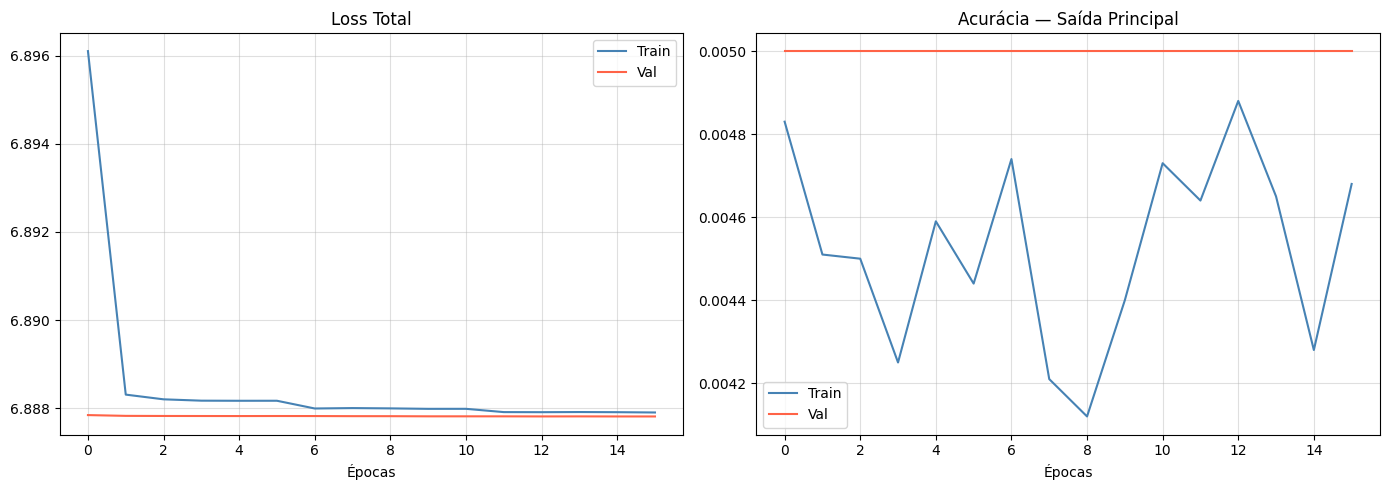

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato')
axes[0].set_title('Loss Total')
axes[0].set_xlabel('Épocas'); axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(history.history['main_output_accuracy'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_main_output_accuracy'], label='Val',   color='tomato')
axes[1].set_title('Acurácia — Saída Principal')
axes[1].set_xlabel('Épocas'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('training_curves_exp003.png', dpi=150)
plt.show()


In [13]:
# Carrega words.txt para nomes legíveis
id_to_name = {}
words_file = DATA_DIR / 'words.txt'
if words_file.exists():
    with open(words_file) as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                id_to_name[parts[0]] = parts[1].split(',')[0]

idx_to_name = {i: id_to_name.get(cid, cid) for i, cid in enumerate(CLASS_NAMES)}
print('Mapeamento carregado. Exemplos:')
for i in range(5):
    print(f'  [{i}] {CLASS_NAMES[i]} → {idx_to_name[i]}')


Mapeamento carregado. Exemplos:
  [0] n01443537 → goldfish
  [1] n01629819 → European fire salamander
  [2] n01641577 → bullfrog
  [3] n01644900 → tailed frog
  [4] n01698640 → American alligator


In [14]:
# Coleta predições completas sobre o val set
all_true, all_pred, all_probs = [], [], []
for imgs, (lbls, _) in val_ds_dual:
    lbl_idx = tf.argmax(lbls, axis=1).numpy()
    probs   = best_model(imgs, training=False)[0].numpy()
    all_true.extend(lbl_idx)
    all_pred.extend(np.argmax(probs, axis=1))
    all_probs.append(probs)

all_true  = np.array(all_true)
all_pred  = np.array(all_pred)
all_probs = np.concatenate(all_probs, axis=0)

# Top-5 (corrigido: SparseTopK com labels sparse, não one-hot)
top5_metric = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)
top5_metric.update_state(all_true, all_probs)
top5_acc = top5_metric.result().numpy()

per_class_acc = {
    c: (all_pred[all_true == c] == c).mean()
    for c in range(NUM_CLASSES) if (all_true == c).sum() > 0
}
sorted_acc = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)

print(f"{'='*50}")
print(f"  Top-1 Accuracy  : {(all_true == all_pred).mean()*100:.2f}%")
print(f"  Top-5 Accuracy  : {top5_acc*100:.2f}%")
print(f"  Média per-class : {np.mean(list(per_class_acc.values()))*100:.2f}%")
print(f"  Melhor classe   : {idx_to_name.get(sorted_acc[0][0])} ({sorted_acc[0][1]*100:.1f}%)")
print(f"  Pior classe     : {idx_to_name.get(sorted_acc[-1][0])} ({sorted_acc[-1][1]*100:.1f}%)")
print(f"{'='*50}")


  Top-1 Accuracy  : 0.50%
  Top-5 Accuracy  : 2.50%
  Média per-class : 0.50%
  Melhor classe   : American lobster (100.0%)
  Pior classe     : acorn (0.0%)


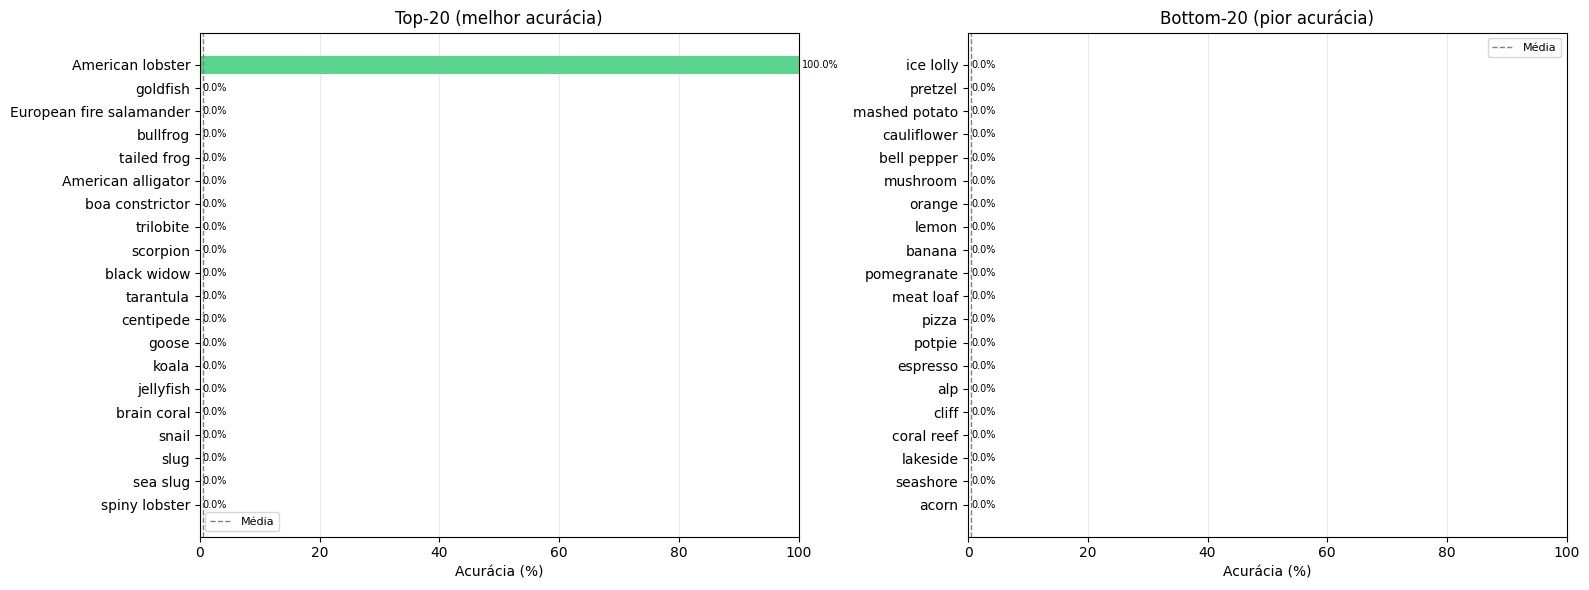

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, color in [
    (axes[0], sorted_acc[:20],  'Top-20 (melhor acurácia)', '#2ecc71'),
    (axes[1], sorted_acc[-20:], 'Bottom-20 (pior acurácia)', '#e74c3c'),
]:
    lbls = [idx_to_name.get(c, str(c)) for c, _ in data]
    vals = [v * 100 for _, v in data]
    bars = ax.barh(lbls[::-1], vals[::-1], color=color, alpha=0.8)
    ax.axvline(np.mean(list(per_class_acc.values())) * 100,
               color='gray', linestyle='--', lw=1, label='Média')
    ax.set_xlabel('Acurácia (%)'); ax.set_title(title)
    ax.set_xlim(0, 100); ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, vals[::-1]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('per_class_exp003.png', dpi=150, bbox_inches='tight')
plt.show()


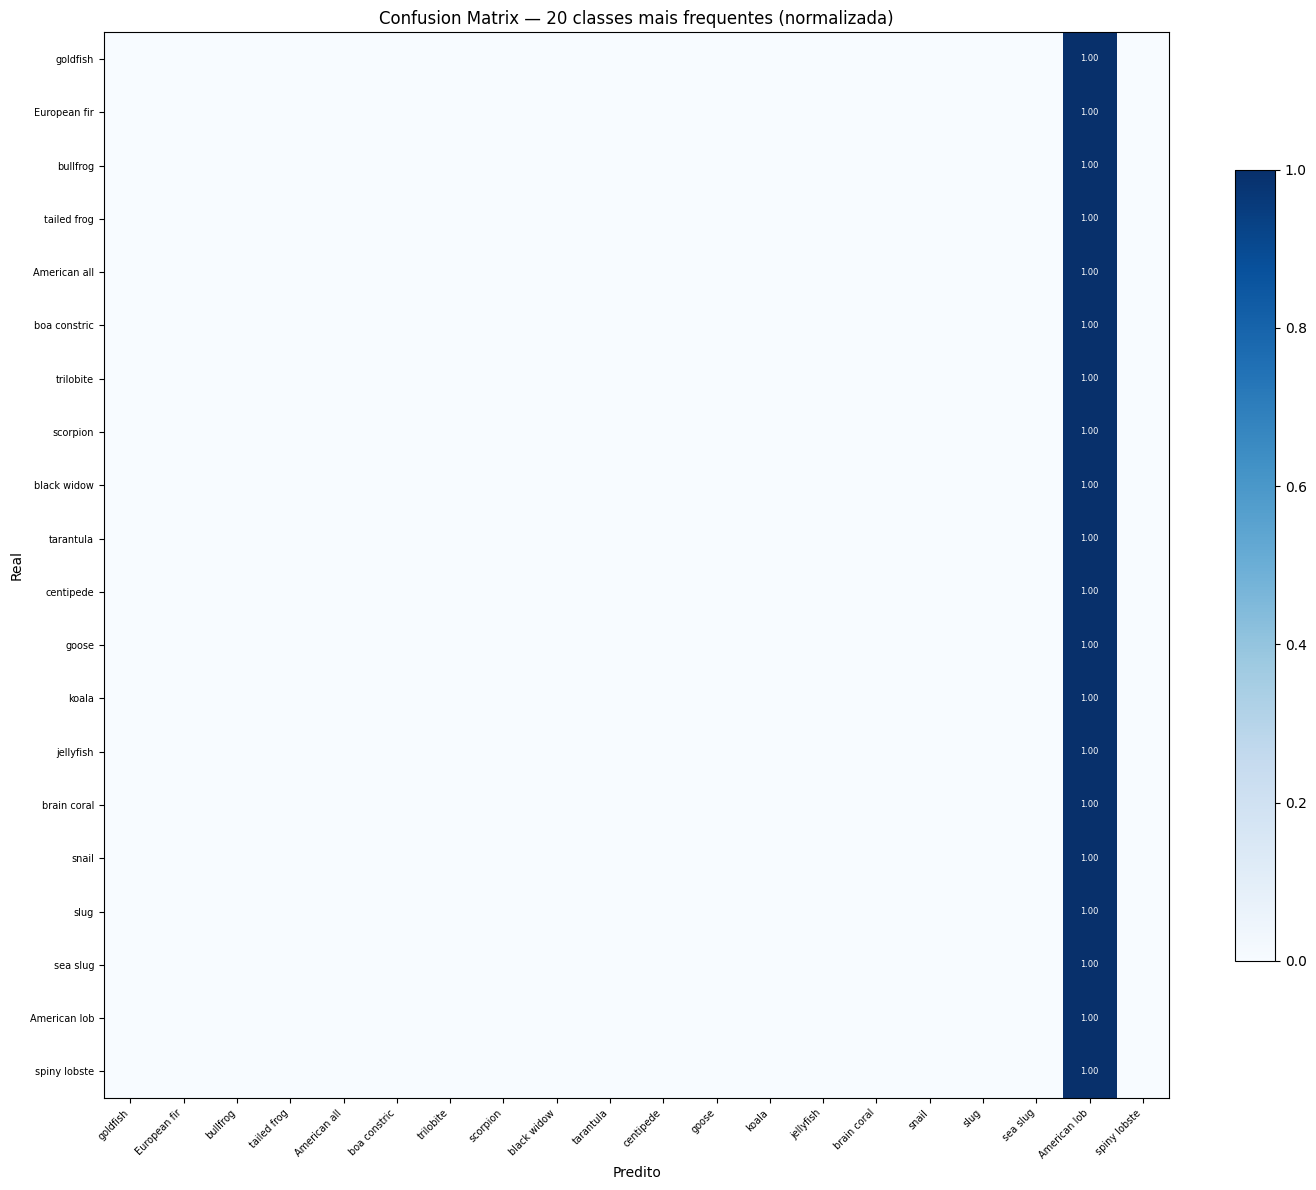

In [16]:
top20_idx = [c for c, _ in sorted(
    ((c, (all_true == c).sum()) for c in range(NUM_CLASSES)), key=lambda x: -x[1]
)[:20]]

mask = np.isin(all_true, top20_idx)
cm   = confusion_matrix(all_true[mask], all_pred[mask], labels=top20_idx)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03)
tick_lbl = [idx_to_name.get(c, str(c))[:12] for c in top20_idx]
ax.set_xticks(range(20)); ax.set_xticklabels(tick_lbl, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(20)); ax.set_yticklabels(tick_lbl, fontsize=7)
ax.set_title('Confusion Matrix — 20 classes mais frequentes (normalizada)')
ax.set_ylabel('Real'); ax.set_xlabel('Predito')
for i, j in itertools.product(range(20), range(20)):
    if cm_n[i, j] > 0.15:
        ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_n[i,j] > 0.5 else 'black', fontsize=6)
plt.tight_layout()
plt.savefig('confusion_matrix_exp003.png', dpi=150, bbox_inches='tight')
plt.show()


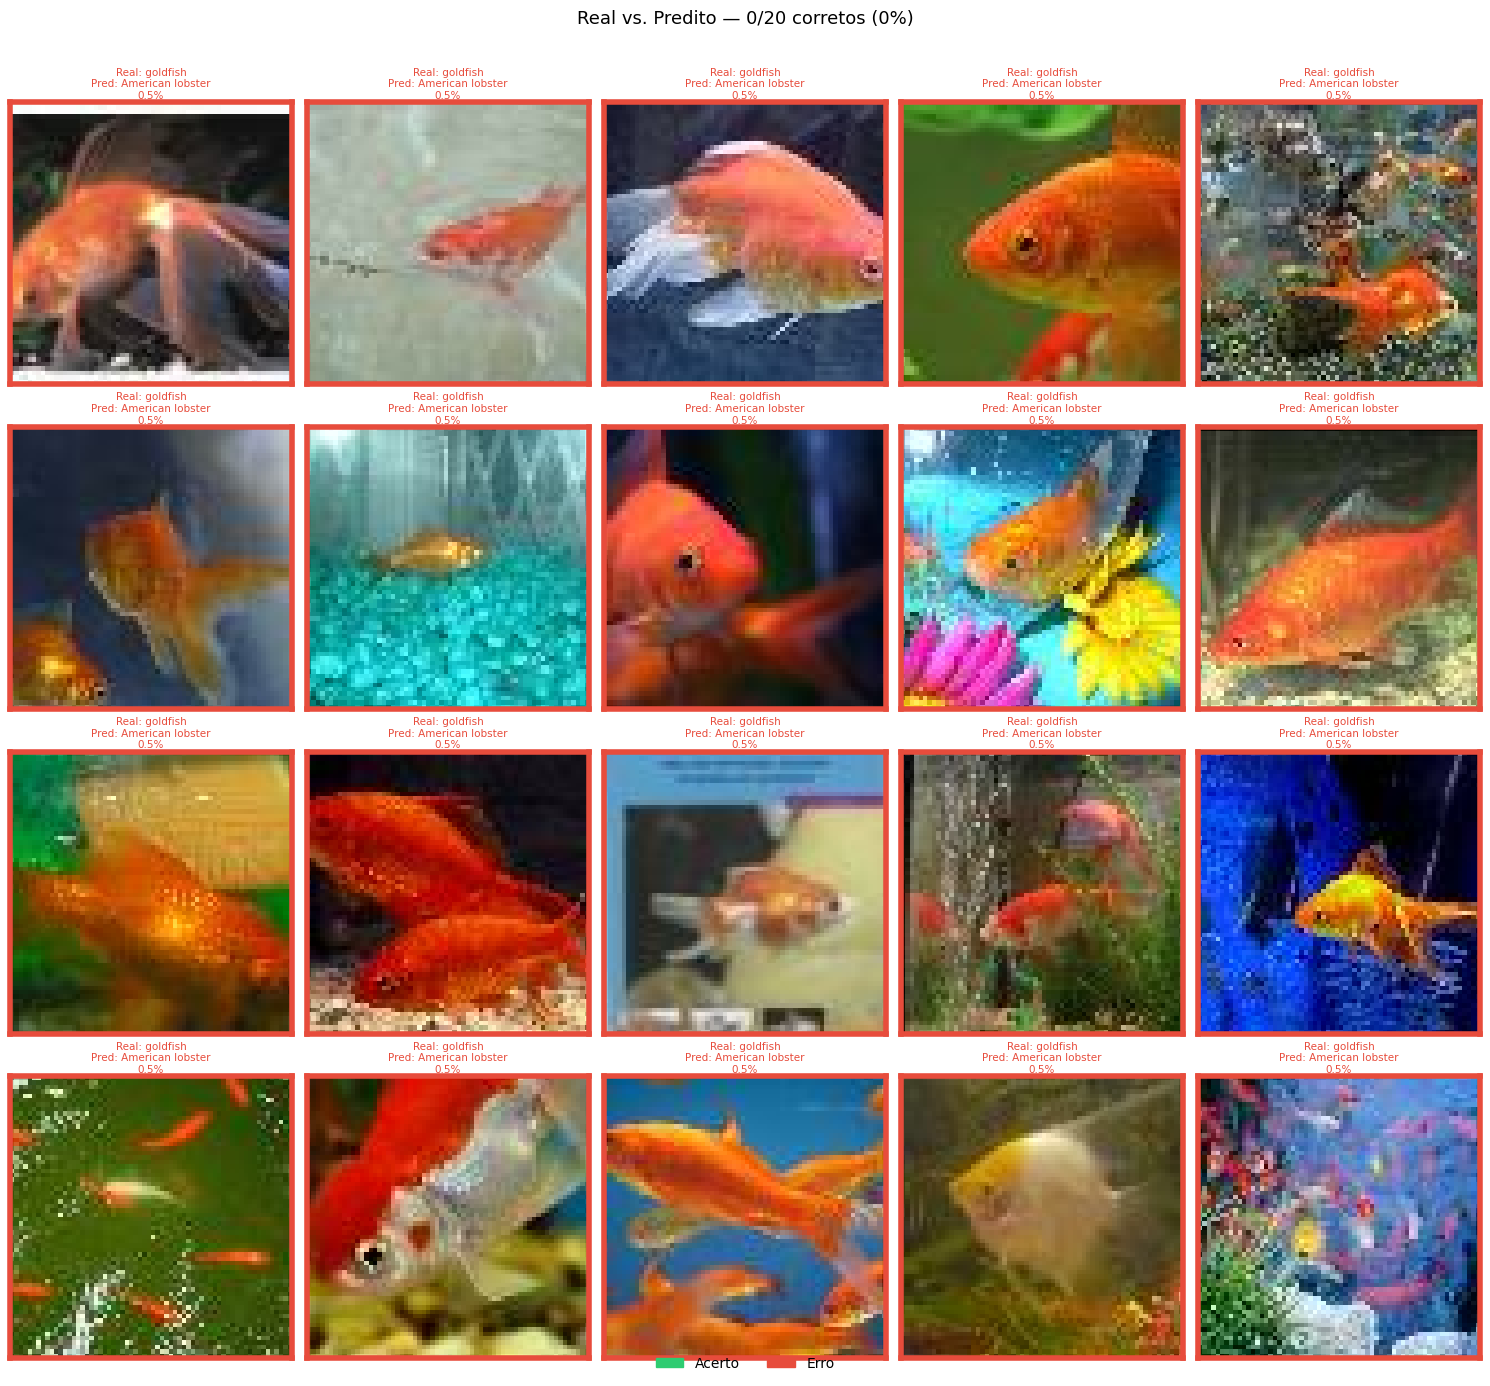

In [17]:
N, COLS = 20, 5
ROWS = math.ceil(N / COLS)

sample_imgs, (sample_lbls, _) = next(iter(val_ds_dual))
sample_imgs = sample_imgs[:N]
true_idx    = tf.argmax(sample_lbls[:N], axis=1).numpy()
probs_main  = best_model(sample_imgs, training=False)[0].numpy()
pred_idx    = np.argmax(probs_main, axis=1)
confs       = np.max(probs_main, axis=1)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS*3, ROWS*3.4))
for i, ax in enumerate(axes.flat[:N]):
    correct = true_idx[i] == pred_idx[i]
    cor = '#2ecc71' if correct else '#e74c3c'
    ax.imshow(sample_imgs[i].numpy())
    for s in ax.spines.values():
        s.set_edgecolor(cor); s.set_linewidth(4)
    ax.set_title(
        f"Real: {idx_to_name.get(true_idx[i], '')}\n"
        f"Pred: {idx_to_name.get(pred_idx[i], '')}\n{confs[i]*100:.1f}%",
        fontsize=7.5, color=cor, pad=3
    )
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for ax in axes.flat[N:]:
    ax.axis('off')

n_ok = (true_idx == pred_idx).sum()
fig.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Acerto'),
    mpatches.Patch(color='#e74c3c', label='Erro')
], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0), frameon=False)
fig.suptitle(f'Real vs. Predito — {n_ok}/{N} corretos ({n_ok/N*100:.0f}%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('real_vs_predito_exp003.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# URLs de imagens públicas cobrindo classes presentes no Tiny ImageNet
TEST_URLS = [
    # goldfish (n01443537)
    ('goldfish',      'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Goldfish3.jpg/320px-Goldfish3.jpg'),
    # tabby cat (n02123045)
    ('tabby cat',     'https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/320px-Cat_November_2010-1a.jpg'),
    # ant (n02165456)
    ('ant',           'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/320px-Camponotus_flavomarginatus_ant.jpg'),
    # school bus (n04376876)
    ('school bus',    'https://upload.wikimedia.org/wikipedia/commons/thumb/8/8e/Iconbus.jpg/320px-Iconbus.jpg'),
    # Egyptian cat (n02124075)
    ('Egyptian cat',  'https://upload.wikimedia.org/wikipedia/commons/thumb/9/94/Sobekhotep_IV_MET_44.4.21.jpg/320px-Sobekhotep_IV_MET_44.4.21.jpg'),
    # monarch butterfly (n02281406)
    ('monarch',       'https://upload.wikimedia.org/wikipedia/commons/thumb/1/18/Monarch_Butterfly_Danaus_plexippus_on_Echinacea_purpurea_1.jpg/320px-Monarch_Butterfly_Danaus_plexippus_on_Echinacea_purpurea_1.jpg'),
]

def predict_url(label, url, top_k=5):
    """Baixa imagem, redimensiona para IMG_SIZE e exibe top-k predições."""
    try:
        r   = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
        img = Image.open(BytesIO(r.content)).convert('RGB')
        img_r = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        arr   = np.array(img_r, dtype=np.float32)[None] / 255.0

        probs     = best_model(arr, training=False)[0][0].numpy()
        top_idx   = np.argsort(probs)[::-1][:top_k]

        fig, axes = plt.subplots(1, 2, figsize=(8, 3.5),
                                 gridspec_kw={'width_ratios': [1, 2]})
        axes[0].imshow(img_r); axes[0].axis('off')
        axes[0].set_title(f'[esperado: {label}]', fontsize=8, color='gray')

        names = [idx_to_name.get(i, str(i)) for i in top_idx]
        vals  = [probs[i]*100 for i in top_idx]
        colors = ['#2ecc71' if label.lower() in n.lower() else '#5b8dd9' for n in names]
        axes[1].barh(names[::-1], vals[::-1], color=colors[::-1])
        axes[1].set_xlabel('Confiança (%)')
        axes[1].set_title('Top-5 Predições')
        axes[1].set_xlim(0, 100)

        plt.suptitle(f'Predição externa — {label}', fontsize=10)
        plt.tight_layout()
        plt.show()

        print(f'  Top-1: {names[0]} ({vals[0]:.1f}%) | esperado: {label}')
    except Exception as e:
        print(f'  Erro ({label}): {e}')

for lbl, url in TEST_URLS:
    predict_url(lbl, url)


  Erro (goldfish): cannot identify image file <_io.BytesIO object at 0x7a14e8b0e8e0>
  Erro (tabby cat): cannot identify image file <_io.BytesIO object at 0x7a14ea6bdd50>
  Erro (ant): cannot identify image file <_io.BytesIO object at 0x7a14eaefb7e0>
  Erro (school bus): cannot identify image file <_io.BytesIO object at 0x7a14eac40720>
  Erro (Egyptian cat): cannot identify image file <_io.BytesIO object at 0x7a14e8b0e8e0>
  Erro (monarch): cannot identify image file <_io.BytesIO object at 0x7a14ea6bdad0>


In [19]:
EXPERIMENTO['resultado_top1'] = round(float(results[3]) * 100, 2)
EXPERIMENTO['resultado_top5'] = round(float(top5_acc) * 100, 2)
EXPERIMENTO['epocas']         = len(history.history['loss'])

log_path   = 'experimentos_log.csv'
fieldnames = ['id', 'hipotese', 'mudancas', 'resultado_top1', 'resultado_top5', 'epocas', 'timestamp']
row = {
    **EXPERIMENTO,
    'mudancas':  ' | '.join(EXPERIMENTO['mudancas']),
    'timestamp': datetime.datetime.now().isoformat(),
}
file_exists = os.path.isfile(log_path)
with open(log_path, 'a', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()
    writer.writerow(row)

print(f'✓ {EXPERIMENTO["id"]} salvo em {log_path}')
print(f'  Top-1: {EXPERIMENTO["resultado_top1"]}% | Top-5: {EXPERIMENTO["resultado_top5"]}% | Épocas: {EXPERIMENTO["epocas"]}')


✓ exp_003 salvo em experimentos_log.csv
  Top-1: 0.49% | Top-5: 2.5% | Épocas: 16


## Resumo — exp_003

| Métrica | Baseline | EXP01 | EXP02 | **EXP03** |
|---|---|---|---|---|
| Top-1 val (principal) | 39.88% | 40.08% | 39.29% | *(preencher)* |
| Top-1 val (auxiliar) | — | 44.76% | 46.58% | *(preencher)* |
| Top-5 val | — | 71.05% | 71.79% | *(preencher)* |
| Épocas | — | 66 | 94 | *(preencher)* |

**Mudanças acumuladas vs baseline:**
- `inception_5a/5b`: canais reduzidos ~30% (exp_001)
- `main_dropout`: 0.4 → 0.55 (exp_002)
- `label_smoothing`: 0.1 em ambas as saídas (exp_003)
- `scheduler`: ReduceLROnPlateau(patience=5, factor=0.5) (exp_003)
- `augmentation`: +RandomBrightness(0.2), rotação 0.1→0.15 (exp_003)
